In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CSV fájl beolvasása
df = pd.read_csv("corvinus_mi2026-g26.csv")

# Alapinformációk
print("Adathalmaz mérete:", df.shape)

# Első 5 sor megjelenítése
df.head()

Adathalmaz mérete: (2108, 10)


,Unnamed: 0,title,Movie_Rating,No_of_Ratings,Format,ReleaseYear,MPAA_Rating,Directed_By,Starring,Price
0,0,Totally Killer,4.3,323,Prime Video,2023.0,R,Nahnatchka Khan,"Kiernan Shipka,Olivia Holt,Julie Bowen",NaN
1,1,Guy Ritchie's The Covenant,4.7,13268,Prime Video,2023.0,R,Guy Ritchie,"Jake Gyllenhaal,Dar Salim,Antony Starr",5.99
2,2,A Million Miles Away,4.9,1126,Prime Video,2023.0,PG,Alejandra Márquez Abella,"Michael Peña,Rosa Salazar",NaN
3,3,Kelce,5.0,570,Prime Video,2023.0,NaN,Don Argott,"Jason Kelce,Travis Kelce,Kylie Kelce,Connor Ba...",NaN
4,4,Despicable Me 3,4.8,31813,Prime Video,2017.0,PG,"Pierre Coffin,Kyle Balda","Steve Carell,Kristen Wiig,Trey Parker",NaN


In [56]:
# Egyedi rendezők lekérdezése
unique_directors = df["Directed_By"].unique()

# "" és "---" kiszűrése + kis/nagybetű egységesítés
unique_directors = [
    director.strip().lower()
    for director in unique_directors
    if pd.notna(director) and director != "" and director != "---"
]

# Duplikációk eltávolítása
unique_directors = set(unique_directors)

print("Különböző rendezők száma:", len(unique_directors))

Különböző rendezők száma: 1374


In [6]:
# Rendezők oszlopának szétbontása
directors = df['Directed_By'].dropna().str.split(',')

# Az összes rendező listába gyűjtése
all_directors = []

for director_list in directors:
    for director in director_list:
        all_directors.append(director.strip())

# DataFrame létrehozása
director_df = pd.DataFrame(all_directors, columns=['Director'])

# Filmek számolása rendezőnként
director_movie_counts = director_df['Director'].value_counts()

In [8]:
# Átlag számítása
average_movies = director_movie_counts.mean()

print(f"Átlagosan ennyi filmet rendeztek: {average_movies:.2f}")

Átlagosan ennyi filmet rendeztek: 1.53


In [10]:
# Medián számítása
median_movies = director_movie_counts.median()

print(f"Medián érték: {median_movies}")

Medián érték: 1.0


In [12]:
# Szórás számítása
std_movies = director_movie_counts.std()

print(f"Szórás: {std_movies:.2f}")

Szórás: 1.28


In [51]:
actors = (
    df["Starring"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
    .str.lower()
)

In [53]:
actors = actors[
    (actors != "") &
    (actors != "---")
]

unique_actors = actors.unique()

print("Különböző színészek száma:", len(unique_actors))

Különböző színészek száma: 3603


In [60]:
# Színészek szétbontása
actors = (
    df[["title", "Starring"]]
    .dropna()
)

actors["Starring"] = (
    actors["Starring"]
    .astype(str)
    .str.split(",")
)

actors = actors.explode("Starring")

# Tisztítás
actors["Starring"] = (
    actors["Starring"]
    .str.strip()
    .str.lower()
)

actors = actors[
    (actors["Starring"] != "") &
    (actors["Starring"] != "---")
]

# Filmek száma színészenként
actor_counts = (
    actors.groupby("Starring")["title"]
    .nunique()
    .sort_values(ascending=False)
)

print(actor_counts.head())

Starring
keanu reeves        15
tom cruise          15
tobin bell          14
daniel radcliffe    14
tyler perry         13
Name: title, dtype: int64


In [30]:
# Egyszerű átlag
average_rating = df['Movie_Rating'].mean()

print(f"Egyszerű átlagos értékelés: {average_rating:.2f}")

# Súlyozott átlag számítása
weighted_average = (
    (df['Movie_Rating'] * df['No_of_Ratings']).sum()
    / df['No_of_Ratings'].sum()
)

print(f"Súlyozott átlagos értékelés: {weighted_average:.2f}")

Egyszerű átlagos értékelés: 4.48
Súlyozott átlagos értékelés: 4.61


In [32]:
# Egyszerű szórás
simple_std = df['Movie_Rating'].std()

# Súlyozott variancia
weighted_variance = (
    (
        df['No_of_Ratings']
        * (
            df['Movie_Rating']
            - (
                (df['Movie_Rating'] * df['No_of_Ratings']).sum()
                / df['No_of_Ratings'].sum()
            )
        ) ** 2
    ).sum()
    / df['No_of_Ratings'].sum()
)

# Súlyozott szórás
weighted_std = np.sqrt(weighted_variance)

print(f"Egyszerű szórás: {simple_std:.2f}")
print(f"Súlyozott szórás: {weighted_std:.2f}")

Egyszerű szórás: 0.26
Súlyozott szórás: 0.20


In [64]:
# Numerikus oszlopok
ratings_count = df["No_of_Ratings"]
movie_rating = df["Movie_Rating"]

# Pearson korreláció
pearson_corr = ratings_count.corr(movie_rating)

# Spearman korreláció
spearman_corr = ratings_count.corr(movie_rating, method="spearman")

print("Pearson korreláció:", pearson_corr)
print("Spearman korreláció:", spearman_corr)

Pearson korreláció: 0.25086495198622394
Spearman korreláció: 0.3782515563813587


Igen, gyenge pozitív kapcsolat látható az értékelések száma és a filmek értékelése között, de ez nem túl erős kapcsolat.
Pearson-korreláció: ≈ 0,25
Spearman-korreláció: ≈ 0,38
Ez azt jelenti, hogy:
- a több értékeléssel rendelkező filmek átlagosan valamivel jobb értékelést kapnak,
- de az értékelések száma önmagában nem jó prediktor,
- a kevés értékeléssel rendelkező filmek között gyakrabban fordulnak elő szélsőséges (nagyon jó vagy nagyon rossz) értékek.

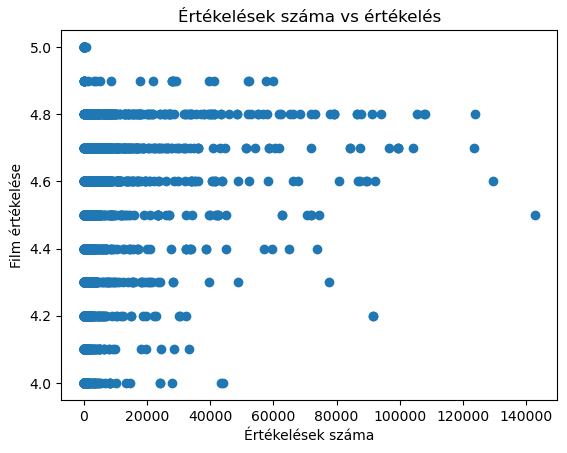

In [66]:
import matplotlib.pyplot as plt

plt.scatter(df["No_of_Ratings"], df["Movie_Rating"])
plt.xlabel("Értékelések száma")
plt.ylabel("Film értékelése")
plt.title("Értékelések száma vs értékelés")

plt.show()

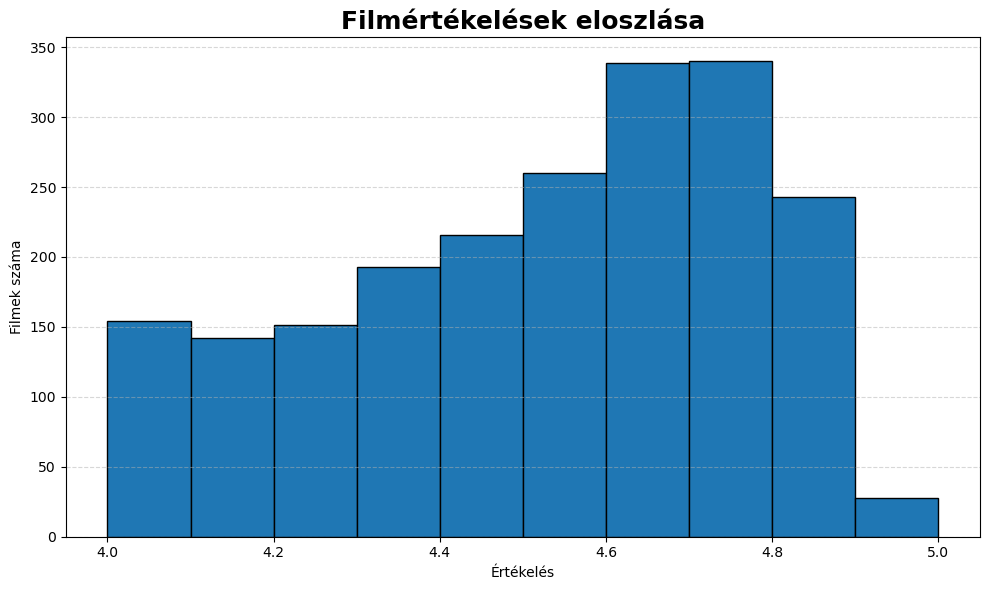

In [76]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bins = np.arange(df["Movie_Rating"].min(), df["Movie_Rating"].max() + 0.1, 0.1)

plt.hist(
    df["Movie_Rating"],
    bins=bins,
    edgecolor="black"
)

plt.xlabel("Értékelés")
plt.ylabel("Filmek száma")
plt.title("Filmértékelések eloszlása", fontsize=18, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

RMSE: 0.255
R²: 0.019


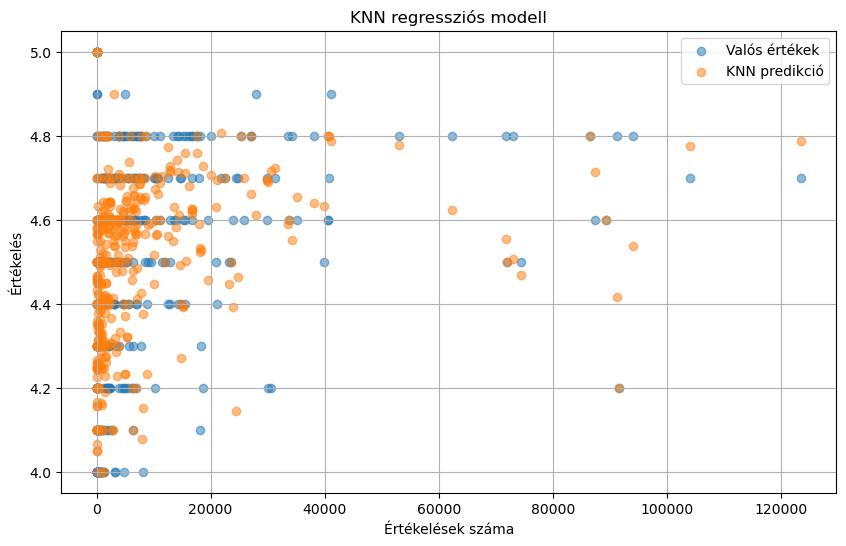

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Bemeneti változók
X = df[["No_of_Ratings"]]

# Célváltozó
y = df["Movie_Rating"]

# Adatok szétválasztása
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Skálázás
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN regressziós modell
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

# Modell tanítása
knn_model.fit(X_train_scaled, y_train)

# Predikció
y_pred = knn_model.predict(X_test_scaled)

# Kiértékelés
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

# Vizualizáció
plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Valós értékek"
)

plt.scatter(
    X_test,
    y_pred,
    alpha=0.5,
    label="KNN predikció"
)

plt.xlabel("Értékelések száma")
plt.ylabel("Értékelés")
plt.title("KNN regressziós modell")

plt.legend()
plt.grid(True)

plt.show()
mse_knn = mse
rmse_knn = rmse
r2_knn = r2

RMSE: 0.249
R²: 0.07
Meredekség: 3.9300630542641395e-06
Metszéspont: 4.453143752104002


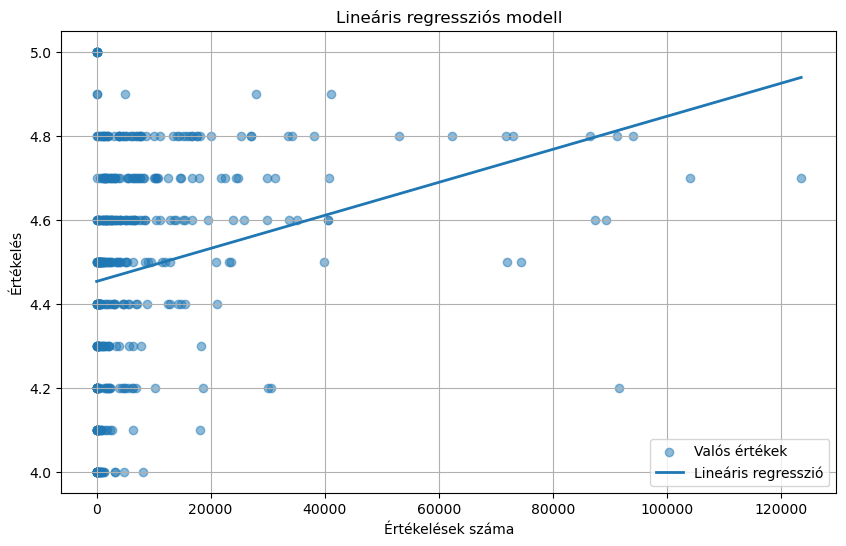

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Bemeneti változók
X = df[["No_of_Ratings"]]

# Célváltozó
y = df["Movie_Rating"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Lineáris regressziós modell
linear_model = LinearRegression()

# Modell tanítása
linear_model.fit(X_train, y_train)

# Predikció
y_pred = linear_model.predict(X_test)

# Kiértékelés
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

# Egyenes paraméterei
print("Meredekség:", linear_model.coef_[0])
print("Metszéspont:", linear_model.intercept_)

# Vizualizáció
plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Valós értékek"
)

# Rendezés szebb vonalhoz
sorted_idx = X_test["No_of_Ratings"].argsort()

plt.plot(
    X_test.iloc[sorted_idx],
    y_pred[sorted_idx],
    linewidth=2,
    label="Lineáris regresszió"
)

plt.xlabel("Értékelések száma")
plt.ylabel("Értékelés")
plt.title("Lineáris regressziós modell")

plt.legend()
plt.grid(True)

plt.show()
mse_linear = mse
rmse_linear = rmse
r2_linear = r2

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KNN Regression"
    ],

    "MSE": [
        mse_linear,
        mse_knn
    ],

    "RMSE": [
        rmse_linear,
        rmse_knn
    ],

    "R²": [
        r2_linear,
        r2_knn
    ]
})

print(comparison)

               Model       MSE      RMSE        R²
0  Linear Regression  0.061754  0.248505  0.070282
1     KNN Regression  0.065169  0.255282  0.018880
